In [ ]:
%pip install wordfreq --break-system-packages
%pip install pandas --break-system-packages
%pip install matplotlib --break-system-packages

Robie scraper dla: Ash Ketchum
Robie scraper dla: Pikachu


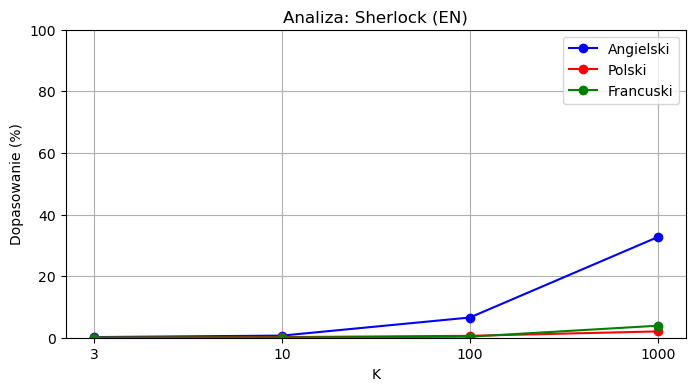

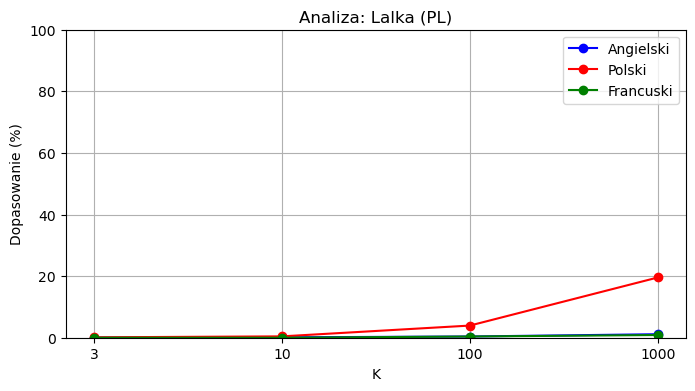

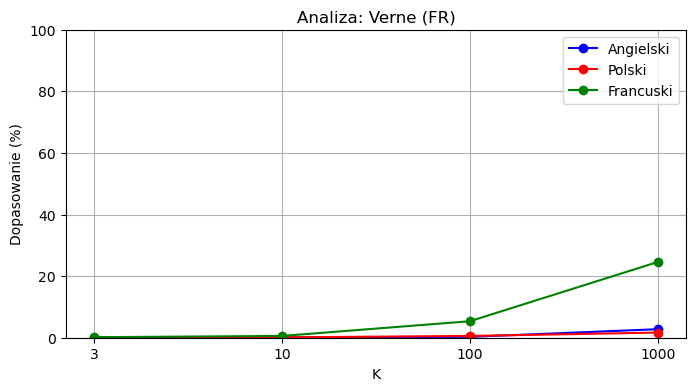

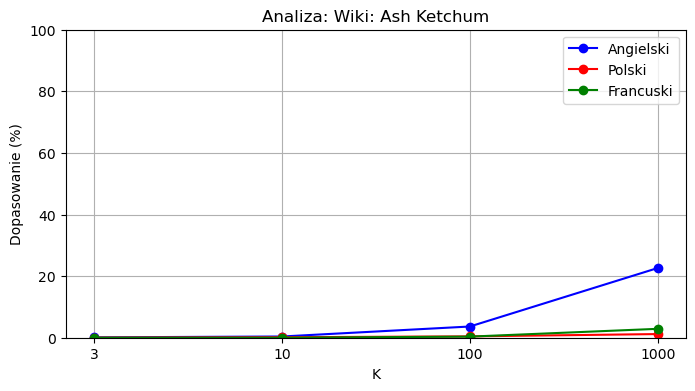

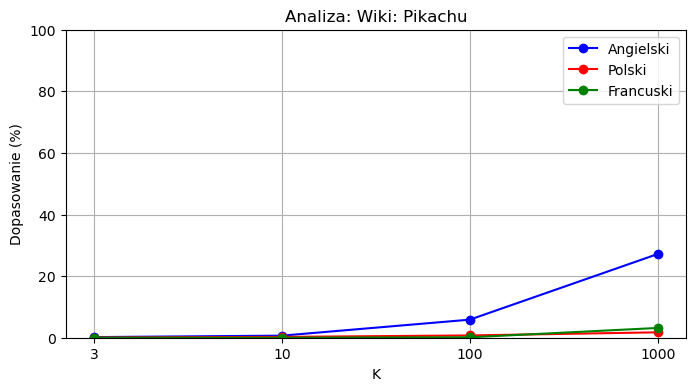

In [16]:
import sys
import json
import os
import argparse
import matplotlib.pyplot as plt
from wordfreq import top_n_list

sys.path.append(os.getcwd())

# Importujemy klasę ze scrapera
from wiki_scraper import Controller

# Ustawienia
K_VALUES = [3, 10, 100, 1000]
results = [] # Tu będziemy zbierać dane do wykresów

# Funkcje pomocnicze
def get_top_words(lang, n):
    return set(top_n_list(lang, n))

def clean_text(raw_text):
    text = raw_text.lower()
    text = ' '.join(text.split())
    text = ''.join(c for c in text if c.isalpha() or c.isspace())
    return text.split()

def calc_score(word_counts, lang_set):
    matches = 0
    total = len(word_counts)
    if total == 0: return 0.0
    
    for word in word_counts:
        if word in lang_set:
            matches += 1
            
    return (matches / total) * 100

def txt_to_json(filename):
    if not os.path.exists(filename):
        print(f"Nie ma pliku: {filename}")
        return False

    with open(filename, 'r', encoding='utf-8') as f:
        text = f.read()

    words = clean_text(text)
    words = words[:5000] # Bierzemy pierwsze 5000 słów
    
    counts = {}
    for w in words:
        counts[w] = counts.get(w, 0) + 1
    
    with open('word-counts.json', 'w', encoding='utf-8') as f:
        json.dump(counts, f)
    return True

# Funkcja, która przelicza procenty i zwraca dane (nie rysuje)
def analyze_data(label, word_counts):
    data = {
        'label': label,
        'en': [],
        'pl': [],
        'fr': []
    }
    
    for k in K_VALUES:
        set_en = get_top_words('en', k)
        set_pl = get_top_words('pl', k)
        set_fr = get_top_words('fr', k)
        
        data['en'].append(calc_score(word_counts, set_en))
        data['pl'].append(calc_score(word_counts, set_pl))
        data['fr'].append(calc_score(word_counts, set_fr))
        
    return data

# Funkcja do rysowania wykresów na końcu
def make_plots(data_list):
    if not data_list:
        print("Brak danych.")
        return

    x_labels = [str(k) for k in K_VALUES]

    for item in data_list:
        plt.figure(figsize=(8, 4))
        
        plt.plot(x_labels, item['en'], marker='o', label='Angielski', color='blue')
        plt.plot(x_labels, item['pl'], marker='o', label='Polski', color='red')
        plt.plot(x_labels, item['fr'], marker='o', label='Francuski', color='green')

        plt.title(f"Analiza: {item['label']}")
        plt.ylabel("Dopasowanie (%)")
        plt.xlabel("K")
        plt.ylim(0, 100)
        plt.grid(True)
        plt.legend()
        plt.show()

# Pliki tekstowe
files = [
    ('sherlock_en.txt', 'Sherlock (EN)'),
    ('sherlock_pl.txt', 'Lalka (PL)'),
    ('20000mil_fr.txt', 'Verne (FR)')
]

for fname, label in files:
    if txt_to_json(fname):
        with open('word-counts.json', 'r', encoding='utf-8') as f:
            counts = json.load(f)
        
        # Dodajemy wyniki do listy
        results.append(analyze_data(label, counts))
        os.remove('word-counts.json')

#Wiki
wiki_list = ["Ash Ketchum", "Pikachu"]

for phrase in wiki_list:
    print(f"Robie scraper dla: {phrase}")
    
    # Argumenty dla scrapera
    args = argparse.Namespace(
        count_words=phrase, summary=None, local=False, analize_relative_word_frequency=None, 
        mode=None, count=None, chart=None, auto_count_words=None, depth=None, wait=None, 
        table=None, number=None, first_row_is_header=False
    )
    
    scraper = Controller(args)
    scraper.run()

    if os.path.exists('word-counts.json'):
        with open('word-counts.json', 'r', encoding='utf-8') as f:
            counts = json.load(f)
            
        results.append(analyze_data(f"Wiki: {phrase}", counts))
        os.remove('word-counts.json')

# Rysujemy wszystko
make_plots(results)

Analizę przeprowadziłem w następujący sposób: sprawdziłem, jaki procent słów występujących w tekście zawierał się w zbiorze k najczęstszych słów w danym języku. Uzyskałem w ten sposób procentowe pokrycie tych dwóch zbiorów.

Dobór języków miał duże znaczenie. Wyraźnie widać różnice w tym, jak szybko rośnie krzywa dla języka angielskiego, a jak dla polskiego czy francuskiego. Wynika to z różnic między budową języków: angielski ma dużo słów pomocniczych (jak the, a, an), które są statystycznie najczęstsze i zawsze wyglądają tak samo. Dzięki temu funkcja dla języka angielskiego rośnie tak szybko.

Wyniki empiryczne pokazują, w którym języku słowa są odmieniane. Krzywa dla języka angielskiego rośnie znacznie szybciej niż dla polskiego czy francuskiego właśnie z tego powodu – brak końcówek ułatwia dopasowanie.

Na Bulbapedii znalezienie artykułu, w którym language_words_with_frequency jest jak najmniejszy, nie było trudne. Ze względu na to, jak wygląda konstrukcja dopasowania języka, należało wziąć możliwie najdłuższy artykuł. Przypomnijmy, dopasowanie liczę ze wzoru:
$D=\frac{\textbf{liczba słów wspólnych z listą Top K}}{\textbf{całkowita liczba słów w tekćcie}}$
Wzór jest zgodny z założeniami zadania (pozwala dopasować język do tekstu), jednak premiuje krótkie teksty. Co ważne, w mojej analizie nie biorę pod uwagę wagi słowa, czyli pospolite "ja" liczę tak samo jak rzadki "abażur", niezależnie od tego, jak często występują w samym języku. Ze względu na wspomniane wady tej metody, nawet krótkie artykuły (zawierające w większości nazwy własne) miały wyższe dopasowanie od tych najdłuższych, "zaśmieconych" żargonem gry.